# 02 · Retrieval mathematics — from words to ranked evidence

> **Core lesson:** all cells execute without external services. Read the *predict → run → explain* questions before each experiment.


## What is a vector and what does cosine measure?

TF-IDF maps each document chunk into a **sparse** vector of weighted word/phrase features.

`tfidf(term, document) ≈ term frequency × inverse document frequency`

Cosine similarity `sim(q,d) = (q·d) / (||q|| ||d||)`. The vectorizer in this curriculum L2-normalizes vectors, so **dot product = cosine similarity**. Repeating a unique relevant phrase can move a chunk up; out-of-vocabulary paraphrases can fail.

**Predict:** "password reset" should retrieve `account`; "rate limit per minute" should retrieve `api`.


In [1]:
from pathlib import Path
import numpy as np
from RAG.src.core import load_documents, chunk_documents, Retriever
docs = load_documents(Path("RAG/data/support_policies.jsonl"))
chunks = chunk_documents(docs, 80, 15)
index = Retriever(chunks)
print("Matrix shape (chunks, vocabulary):", index.matrix.shape)
print("Vector sparsity:", round(1 - index.matrix.nnz / (index.matrix.shape[0] * index.matrix.shape[1]), 4))
print("Sample vocabulary:", sorted(index.vectorizer.get_feature_names_out())[:10])


Matrix shape (chunks, vocabulary): (10, 358)
Vector sparsity: 0.8855
Sample vocabulary: ['00', '00 18', '00 india', '09', '09 00', '18', '18 00', '429', '429 retried', 'accidental']


## Look at real ranked chunks

The score is **not** the probability that the answer is true. This is a retrieval ranking statistic. Record the document, chunk ID and similarity for debugging.


In [2]:
for question in ("How do I reset my password?", "What is the API request limit per minute?"):
    print("\nQUESTION:", question)
    for hit in index.search(question, k=3):
        print(f"  {hit.chunk.doc_id:18} score={hit.score:.3f} {hit.chunk.chunk_id}")



QUESTION: How do I reset my password?
  account            score=0.369 account:0000

QUESTION: What is the API request limit per minute?
  api                score=0.352 api:0000
  privacy            score=0.041 privacy:0000
  escalations        score=0.040 escalations:0000


## Verify cosine numerically

This exposes the fundamental operation rather than hiding it behind a vector database. Compare the raw matrix product with the ranked implementation (which rounds to six decimal places).


In [3]:
q = "password reset link"
qv = index.vectorizer.transform([q])
cosines = (index.matrix @ qv.T).toarray().ravel()
top = int(np.argmax(cosines))
print("Top retrieved source:", chunks[top].doc_id)
print("Raw cosine:", round(float(cosines[top]), 6))
print("Retriever cosine:", index.search(q, 1)[0].score)
assert abs(float(cosines[top]) - index.search(q, 1)[0].score) < 1e-6


Top retrieved source: account
Raw cosine: 0.392933
Retriever cosine: 0.392933


## Sparse lexical vectors vs dense semantic vectors

**This reference implementation is TF-IDF, not a pretrained embedding model.** Dense sentence embeddings encode learned semantic patterns (better for some paraphrases), but require a model download, model-version control and additional compute. `TruncatedSVD` on TF-IDF can produce a dense **latent semantic analysis** representation; it is *not* equivalent to a pretrained neural embedding model.

Compare outputs before replacing the baseline. The point of a vector DB is indexing, filtering and search at scale; it does not confer semantic understanding by itself.


In [4]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
dimensions = min(4, index.matrix.shape[0] - 1, index.matrix.shape[1] - 1)
lsa = TruncatedSVD(n_components=dimensions, random_state=7)
dense_corpus = lsa.fit_transform(index.matrix)
dense_query = lsa.transform(index.vectorizer.transform(["password reset link"]))
lsa_scores = cosine_similarity(dense_query, dense_corpus).ravel()
print("LSA dense matrix shape:", dense_corpus.shape)
print("TF-IDF rank-1:", index.search("password reset link", 1)[0].chunk.doc_id)
print("LSA rank-1:", chunks[int(np.argmax(lsa_scores))].doc_id)


LSA dense matrix shape: (10, 4)
TF-IDF rank-1: account
LSA rank-1: account


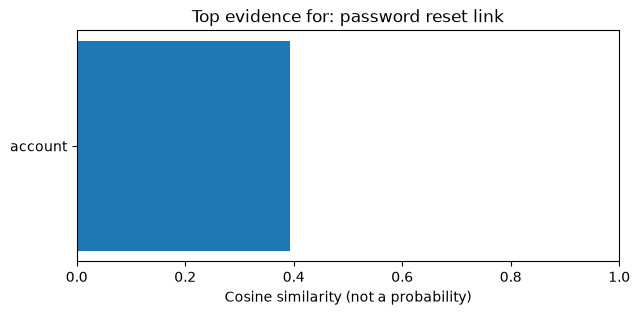

In [5]:
import matplotlib.pyplot as plt
top_hits = index.search("password reset link", k=5)
labels = [h.chunk.doc_id for h in top_hits][::-1]
values = [h.score for h in top_hits][::-1]
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(labels, values)
ax.set(xlabel="Cosine similarity (not a probability)", title="Top evidence for: password reset link", xlim=(0, 1))
plt.show()

## Challenge

1. Paraphrase "password reset" as "forgot my credentials". Does lexical ranking change?
2. Double `k`. How does context breadth grow, and why might generation become *less* faithful?
3. Explain why the top cosine score cannot be used as a calibrated confidence percentage.

**Next:** Use the retrieved evidence safely in **03_grounded_generation**.
